### 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

In [2]:
dataset_path = 'dataset/Base.csv'
df = pd.read_csv(dataset_path)
print(f"Dataset caricato. Shape originale: {df.shape}")
df.head()

Dataset caricato. Shape originale: (1000000, 32)


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,...,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,device_fraud_count,month
0,0,0.3,0.986506,-1,25,40,0.006735,102.453711,AA,1059,...,0,1500.0,0,INTERNET,16.224843,linux,1,1,0,0
1,0,0.8,0.617426,-1,89,20,0.010095,-0.849551,AD,1658,...,0,1500.0,0,INTERNET,3.363854,other,1,1,0,0
2,0,0.8,0.996707,9,14,40,0.012316,-1.490386,AB,1095,...,0,200.0,0,INTERNET,22.730559,windows,0,1,0,0
3,0,0.6,0.475100,11,14,30,0.006991,-1.863101,AB,3483,...,0,200.0,0,INTERNET,15.215816,linux,1,1,0,0
4,0,0.9,0.842307,-1,29,40,5.742626,47.152498,AA,2339,...,0,200.0,0,INTERNET,3.743048,other,0,1,0,0


# Undersampling

In [3]:
fraud = df[df['fraud_bool'] == 1]
legal = df[df['fraud_bool'] == 0]
# Sottocampioniamo la classe "legal" per eguagliare il numero di frodi
legal_downsampled = resample(legal, replace=False, n_samples=len(fraud), random_state=42)
balanced_df = pd.concat([fraud, legal_downsampled])

# Encoding

In [4]:
# Trasformiamo le colonne di testo in colonne booleane (0 o 1)
cat_cols = ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']
df_final = pd.get_dummies(balanced_df, columns=cat_cols, drop_first=True)
print(f"Dataset bilanciato. Totale campioni: {len(df_final)}")
print(f"Feature dopo encoding: {df_final.shape[1]}")
df_final.head()

Dataset bilanciato. Totale campioni: 22058
Feature dopo encoding: 48


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,zip_count_4w,velocity_6h,...,housing_status_BC,housing_status_BD,housing_status_BE,housing_status_BF,housing_status_BG,source_TELEAPP,device_os_macintosh,device_os_other,device_os_windows,device_os_x11
43,1,0.9,0.570800,-1,157,60,0.005908,35.337538,4079,8139.265753,...,False,False,False,False,False,False,False,False,True,False
140,1,0.1,0.993219,-1,67,20,0.015331,92.120139,1192,8330.727428,...,False,False,False,False,False,False,False,False,True,False
284,1,0.8,0.794351,-1,376,60,17.925951,41.422110,815,9747.407396,...,False,False,False,False,False,False,False,False,False,False
314,1,0.7,0.090000,-1,58,50,0.004134,-1.244047,4011,8036.901841,...,False,False,False,False,False,False,False,False,True,False
561,1,0.9,0.998248,31,45,30,0.010165,33.067538,525,6883.814598,...,False,False,False,False,False,False,False,False,True,False


## Separazione feature e target

In [5]:
# --- Feature Selection: selezioniamo le feature più correlate con fraud_bool ---
n_features = 6  # = numero di qubit

# Calcolo della correlazione assoluta di ogni feature con il target
correlations = df_final.corr()['fraud_bool'].drop('fraud_bool').abs().sort_values(ascending=False)
print('=== Top 10 feature per correlazione con fraud_bool ===')
print(correlations.head(10))
print()

# Selezioniamo le top n_features
selected_features = correlations.head(n_features).index.tolist()
print(f'Feature selezionate ({n_features}): {selected_features}')

# Separiamo X e y
y = df_final['fraud_bool'].values
X_selected = df_final[selected_features].values

print(f'Shape X selezionato: {X_selected.shape}')
print(f'Shape y: {y.shape}')


=== Top 10 feature per correlazione con fraud_bool ===
device_os_windows                   0.334975
credit_risk_score                   0.298969
customer_age                        0.276682
proposed_credit_limit               0.273402
keep_alive_session                  0.233486
income                              0.231250
date_of_birth_distinct_emails_4w    0.203580
has_other_cards                     0.197788
device_os_other                     0.190257
housing_status_BE                   0.187980
Name: fraud_bool, dtype: float64

Feature selezionate (6): ['device_os_windows', 'credit_risk_score', 'customer_age', 'proposed_credit_limit', 'keep_alive_session', 'income']
Shape X selezionato: (22058, 6)
Shape y: (22058,)


In [6]:
# Analisi delle Componenti Principali (PCA)

# 1. Varianza spiegata: quanto "pesa" ogni componente?
print("Rapporto di varianza spiegata (prime 6 PC):")
for i, v in enumerate(pca.explained_variance_ratio_[:6]):
    print(f"PC{i+1}: {v:.4f}")

# 2. Loadings: quali feature originali compongono ogni PC?
# Nota: usiamo df_final.drop(columns=['fraud_bool']).columns per i nomi delle colonne
feature_names = df_final.drop(columns=['fraud_bool']).columns

loadings = pd.DataFrame(
    pca.components_[:6], 
    columns=feature_names,
    index=[f'PC{i+1}' for i in range(6)]
)

print("\nTop 5 feature contribuenti per ogni componente:")
for pc in loadings.index:
    print(f"\n{pc}:")
    # Mostriamo le feature con il valore assoluto più alto (maggior influenza)
    print(loadings.loc[pc].abs().sort_values(ascending=False).head(5))


Rapporto di varianza spiegata (prime 6 PC):


NameError: name 'pca' is not defined

### 2

C:\Users\matti\AppData\Local\Temp\ipykernel_18164\499011539.py:6: DeprecationWarning: The class ``qiskit.circuit.library.data_preparation._zz_feature_map.ZZFeatureMap`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the zz_feature_map function as a replacement. Note that this will no longer return a BlueprintCircuit, but just a plain QuantumCircuit.
  feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=1, entanglement='linear')


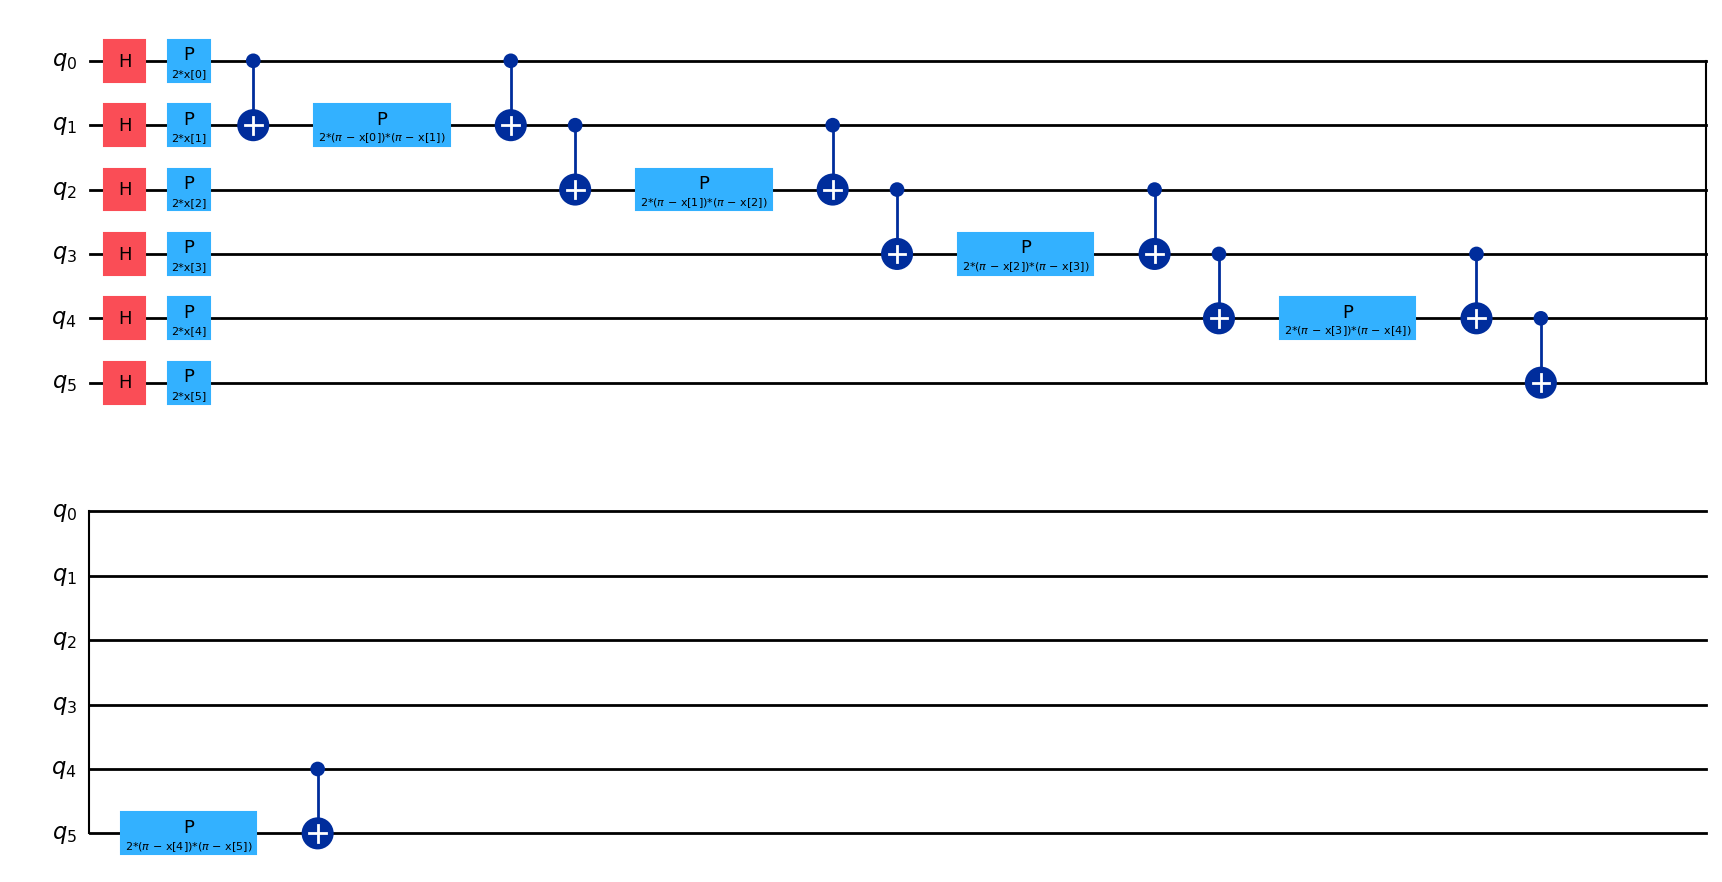

In [7]:
from qiskit.circuit.library import ZZFeatureMap

num_qubits = 6

# reps = 2 indica quante volte ripetere il pattern di encoding (maggiore profondità = più complessità catturata)
feature_map = ZZFeatureMap(feature_dimension=num_qubits, reps=1, entanglement='linear')

# Visualizziamo il circuito per capire come vengono mappati i dati
feature_map.decompose().draw(output='mpl')

### 3

# Split dataset

In [8]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# --- 1. StandardScaler sulle feature selezionate ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# --- 2. Split: 80% train, 20% test ---
X_train_all, X_test_raw, y_train_all, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# --- 3. Riduzione del training set a 500 campioni bilanciati ---
# Con un dataset piccolo, SPSA può fare molte più iterazioni nello stesso tempo
train_size = 500
X_train_small, _, y_train_small, _ = train_test_split(
    X_train_all, y_train_all, train_size=train_size, stratify=y_train_all, random_state=42
)

# --- 4. Scaling in [0, pi] per compatibilità con i gate quantistici ---
q_scaler = MinMaxScaler(feature_range=(0, np.pi))
X_train = q_scaler.fit_transform(X_train_small)
X_test = q_scaler.transform(X_test_raw)
y_train = y_train_small

print(f"Training set: {X_train.shape[0]} campioni (ridotto da {X_train_all.shape[0]})")
print(f"Test set: {X_test.shape[0]} campioni")
print(f"Feature per ogni campione: {X_train.shape[1]}")


Training set: 500 campioni (ridotto da 17646)
Test set: 4412 campioni
Feature per ogni campione: 6


In [17]:
from sklearn.svm import SVC

svc = SVC()
_ = svc.fit(X_train, y_train)

train_score_c4 = svc.score(X_train, y_train)
test_score_c4 = svc.score(X_test, y_test)

print(f"Classical SVC on the training dataset: {train_score_c4:.2f}")
print(f"Classical SVC on the test dataset:     {test_score_c4:.2f}")


Classical SVC on the training dataset: 0.74
Classical SVC on the test dataset:     0.71


In [18]:
train_score_q4 = vqc.score(X_train, y_train)
test_score_q4 = vqc.score(X_test, y_test)

print(f"Quantum VQC on the training dataset: {train_score_q4:.2f}")
print(f"Quantum VQC on the test dataset:     {test_score_q4:.2f}")


Quantum VQC on the training dataset: 0.60
Quantum VQC on the test dataset:     0.57


# Creazione ansatz

C:\Users\matti\AppData\Local\Temp\ipykernel_18164\965960060.py:3: DeprecationWarning: The class ``qiskit.circuit.library.n_local.real_amplitudes.RealAmplitudes`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use the function qiskit.circuit.library.real_amplitudes instead.
  ansatz = RealAmplitudes(num_qubits=num_qubits, reps=2, entanglement='full')


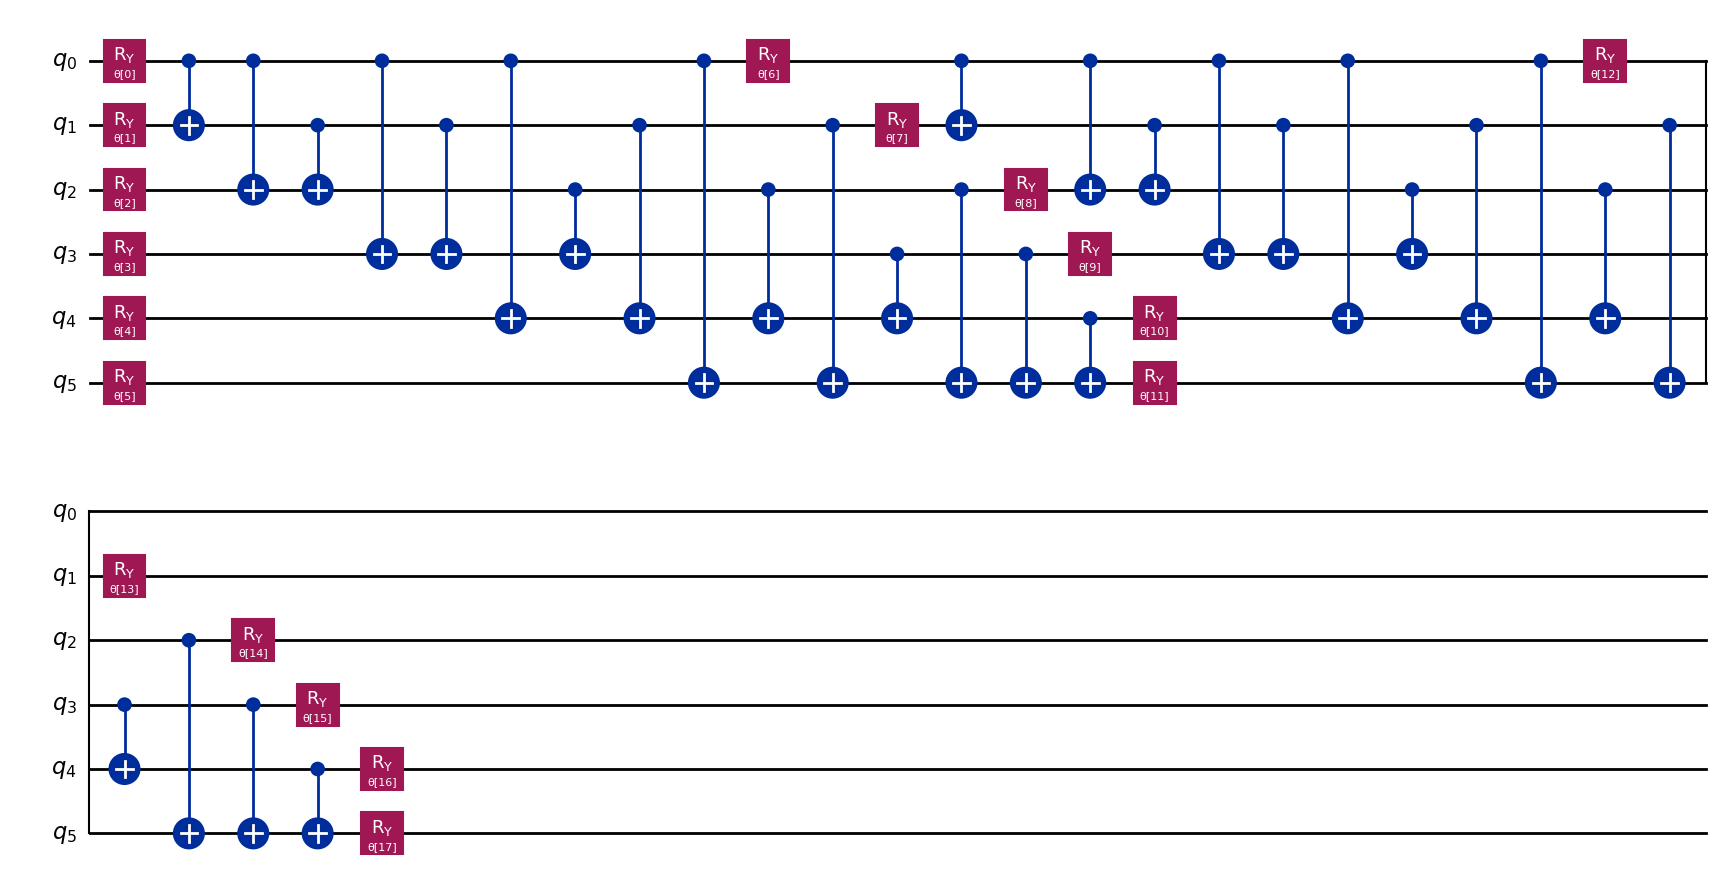

In [9]:
from qiskit.circuit.library import RealAmplitudes

ansatz = RealAmplitudes(num_qubits=num_qubits, reps=2, entanglement='full')

ansatz.decompose().draw(output='mpl')

Circuito configurato per 6 qubit.
Numero di parametri addestrabili: 18


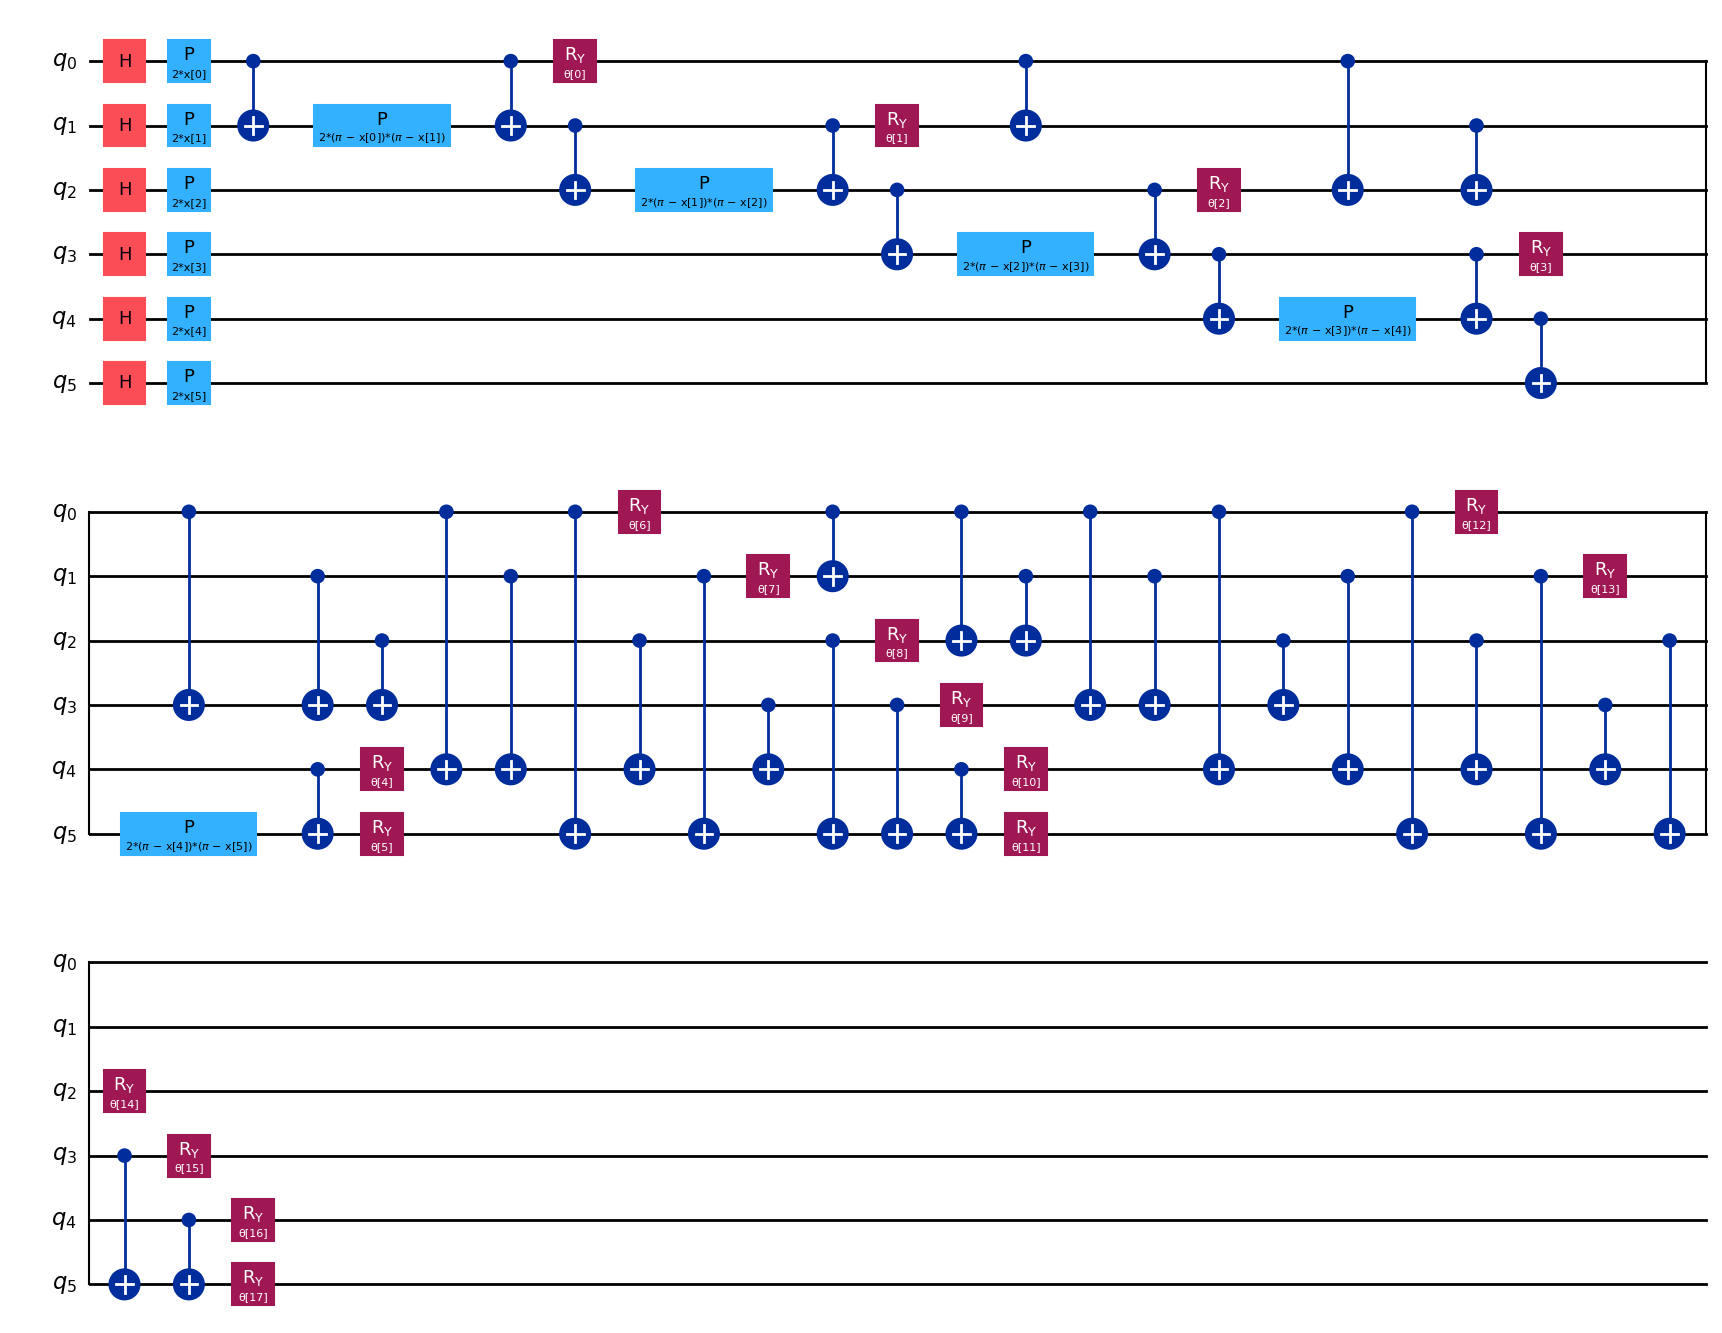

In [10]:
circuit = feature_map.compose(ansatz)
print(f"Circuito configurato per {num_qubits} qubit.")
print(f"Numero di parametri addestrabili: {ansatz.num_parameters}")

circuit.decompose().draw(output='mpl')

Tipo Feature Map: ZZFeatureMap (reps=1, entanglement=linear)
Tipo Ansatz: RealAmplitudes (reps=2, entanglement=full)
Numero di qubit: 6
Profondità circuito: 2
Numero di parametri addestrabili: 18


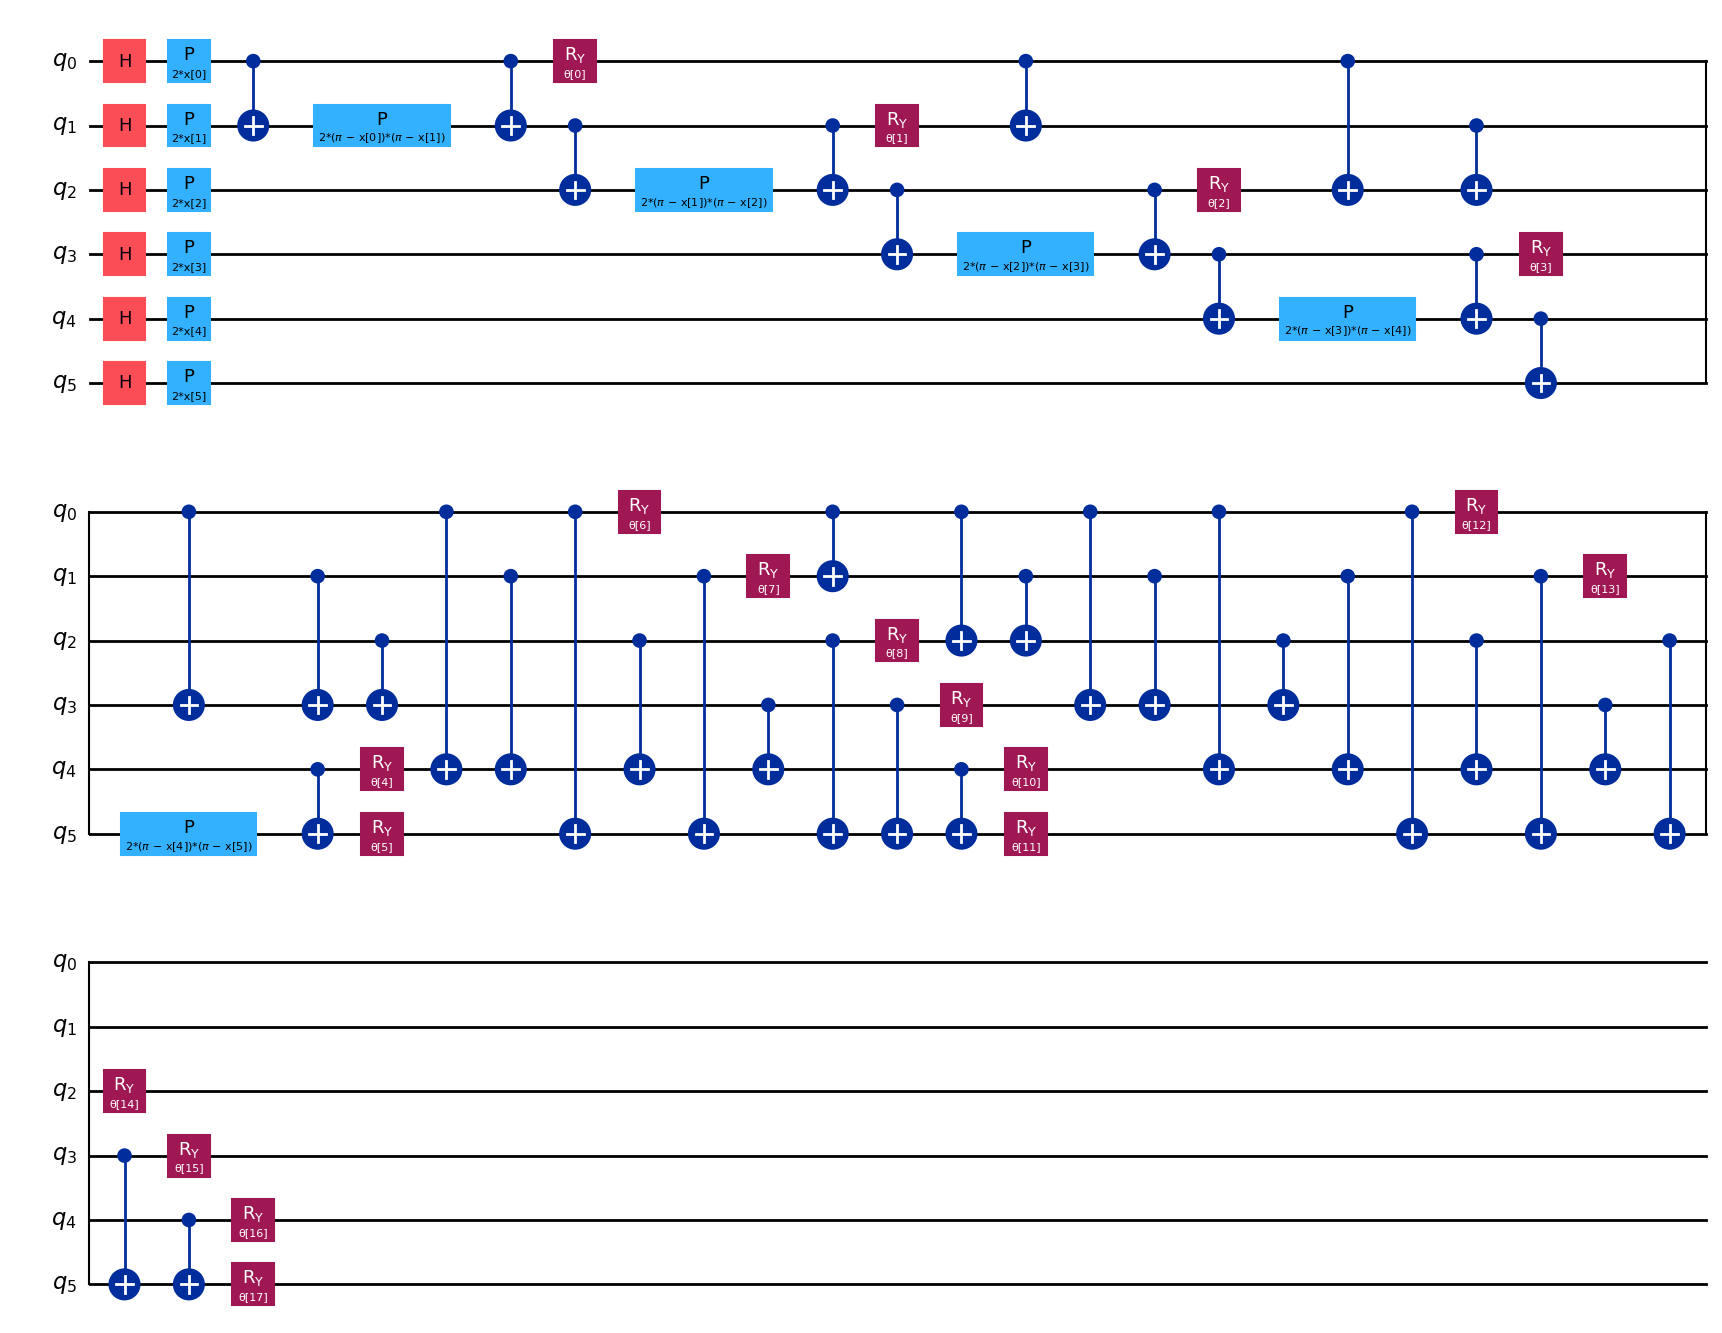

In [11]:
# Combiniamo il circuito completo per visualizzazione
circuit = feature_map.compose(ansatz)
# Info sul circuito
print(f"Tipo Feature Map: ZZFeatureMap (reps=1, entanglement=linear)")
print(f"Tipo Ansatz: RealAmplitudes (reps=2, entanglement=full)")
print(f"Numero di qubit: {num_qubits}")
print(f"Profondità circuito: {circuit.depth()}")
print(f"Numero di parametri addestrabili: {ansatz.num_parameters}")
circuit.decompose().draw(output='mpl')

# Setup VQC

In [12]:
from qiskit_algorithms.optimizers import COBYLA
from qiskit_machine_learning.algorithms import VQC
from qiskit.primitives import StatevectorSampler

import matplotlib.pyplot as plt
from IPython.display import clear_output

# --- COBYLA: ottimizzatore deterministico, converge meglio di SPSA ---
maxiter = 300
loss_values = []

def callback_vqc(*args):
    if len(args) == 5:
        obj_value = args[2]
    else:
        obj_value = args[1]
        
    loss_values.append(obj_value)
    
    if len(loss_values) % 25 == 0:
        print(f"Iterazione {len(loss_values)}/{maxiter} - Loss attuale: {obj_value:.4f}")

optimizer = COBYLA(maxiter=maxiter)

# Inizializzazione parametri vicino a zero (evita barren plateaus)
initial_point = np.random.uniform(-0.1, 0.1, ansatz.num_parameters)
print(f"Numero parametri: {ansatz.num_parameters}")
print(f"Iterazioni COBYLA: {maxiter}")

vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    optimizer=optimizer,
    sampler=StatevectorSampler(),
    callback=callback_vqc,
    initial_point=initial_point
)


No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


Numero parametri: 18
Iterazioni COBYLA: 300


### 4

# Training

Avvio addestramento: 300 iterazioni COBYLA su 500 campioni...

Addestramento completato in 1310.6s
Accuracy Training: 60.00%
Accuracy Test:     57.39%


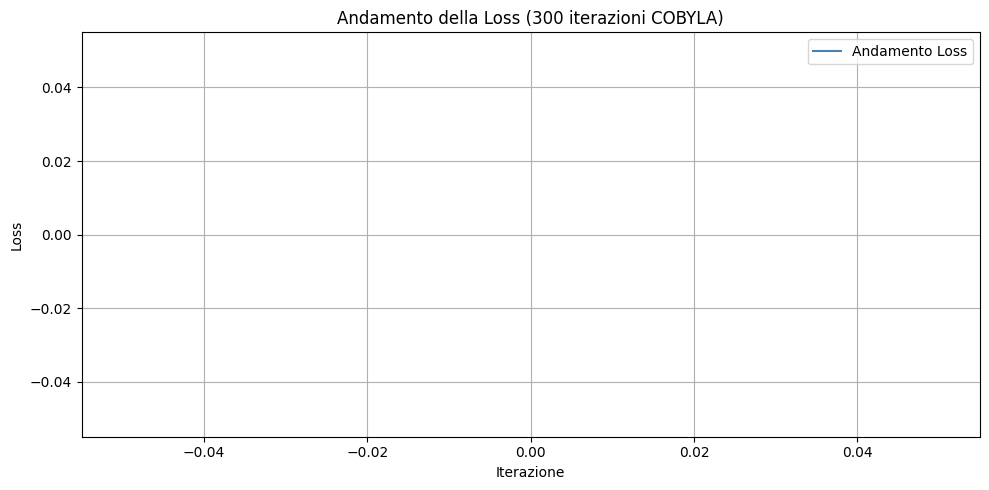

In [13]:
import time

print(f"Avvio addestramento: {maxiter} iterazioni COBYLA su {X_train.shape[0]} campioni...")
start_time = time.time()

vqc.fit(X_train, y_train)

duration = time.time() - start_time
print(f"\nAddestramento completato in {duration:.1f}s")

test_score = vqc.score(X_test, y_test)
train_score = vqc.score(X_train, y_train)
print(f"Accuracy Training: {train_score:.2%}")
print(f"Accuracy Test:     {test_score:.2%}")

plt.figure(figsize=(10, 5))
plt.plot(loss_values, label='Andamento Loss', color='steelblue')
plt.title(f'Andamento della Loss ({maxiter} iterazioni COBYLA)')
plt.xlabel('Iterazione')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Valutazioni

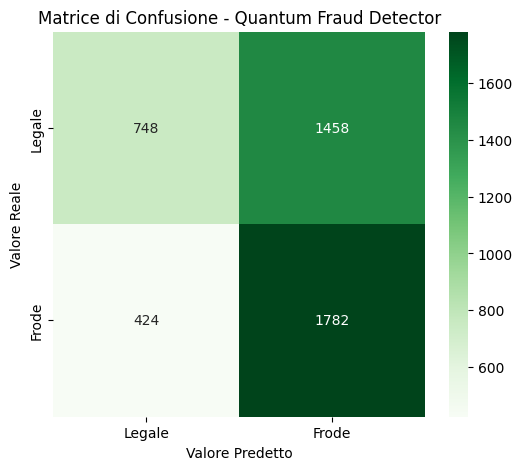


--- Report di Classificazione Dettagliato ---
              precision    recall  f1-score   support

      Legale       0.64      0.34      0.44      2206
       Frode       0.55      0.81      0.65      2206

    accuracy                           0.57      4412
   macro avg       0.59      0.57      0.55      4412
weighted avg       0.59      0.57      0.55      4412



In [14]:
from sklearn.metrics import classification_report, confusion_matrix

# --- Predizioni sul test set ---
y_pred = vqc.predict(X_test)

# --- Matrice di Confusione ---
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Legale', 'Frode'], 
            yticklabels=['Legale', 'Frode'])
plt.title('Matrice di Confusione - Quantum Fraud Detector')
plt.xlabel('Valore Predetto')
plt.ylabel('Valore Reale')
plt.show()

# --- Report dettagliato ---
print('\n--- Report di Classificazione Dettagliato ---')
print(classification_report(y_test, y_pred, target_names=['Legale', 'Frode']))